In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [97]:
def crop_four_corners(img):
    h, w = img.shape[:2]
    
    # Cắt 4 góc
    top_left = img[:h//2, :w//2]       # Góc trên trái
    top_right = img[:h//2, w - w//2:]  # Góc trên phải
    bottom_left = img[h - h//2:, :w//2] # Góc dưới trái
    bottom_right = img[h - h//2:, w - w//2:] # Góc dưới phải
    
    return top_left, top_right, bottom_left, bottom_right


In [98]:
def zoom_in_on_corner(corner_img):
    zoomed = cv2.resize(corner_img, None, fx=4.0, fy=4.0, interpolation=cv2.INTER_CUBIC)
    return zoomed

In [99]:
def preprocess_for_qr(image):
    # Chuyển ảnh sang grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
    # Cân bằng histogram để cải thiện độ tương phản
    eq = cv2.equalizeHist(gray)
    
    # Áp dụng ngưỡng nhị phân (binary thresholding)
    _, thresholded = cv2.threshold(eq, 127, 255, cv2.THRESH_BINARY)
    
    # Làm nét ảnh
  
    sharpened = cv2.GaussianBlur(thresholded, (0, 0), 3)

    
    return sharpened


In [100]:
def detect_qr_in_zoomed_corners(img):
    corners = crop_four_corners(img)
    detector = cv2.QRCodeDetector()

    # Tạo 1 figure với grid 2x2
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))

    for i, corner in enumerate(corners):
        zoomed_corner = zoom_in_on_corner(corner)
        img_check = preprocess_for_qr(zoomed_corner)
        
        # Hiển thị hình ảnh phóng to trên các axes của subplot
        ax = axes[i // 2, i % 2]  # Chọn axes trong grid 2x2
        ax.imshow(img_check, cmap='gray')
        ax.set_title(f"Corner {i + 1}")
        ax.axis('off')  # Tắt hiển thị trục
        
        # Quét QR
        data, bbox, _ = detector.detectAndDecode(img_check)
        
        if data:
            plt.show()  # Hiển thị ngay khi tìm thấy QR
            return data  # Trả về dữ liệu QR khi tìm thấy

    plt.show()  # Hiển thị ảnh sau khi đã vẽ tất cả các góc
    return None  # Nếu không tìm thấy QR trong bất kỳ góc nào

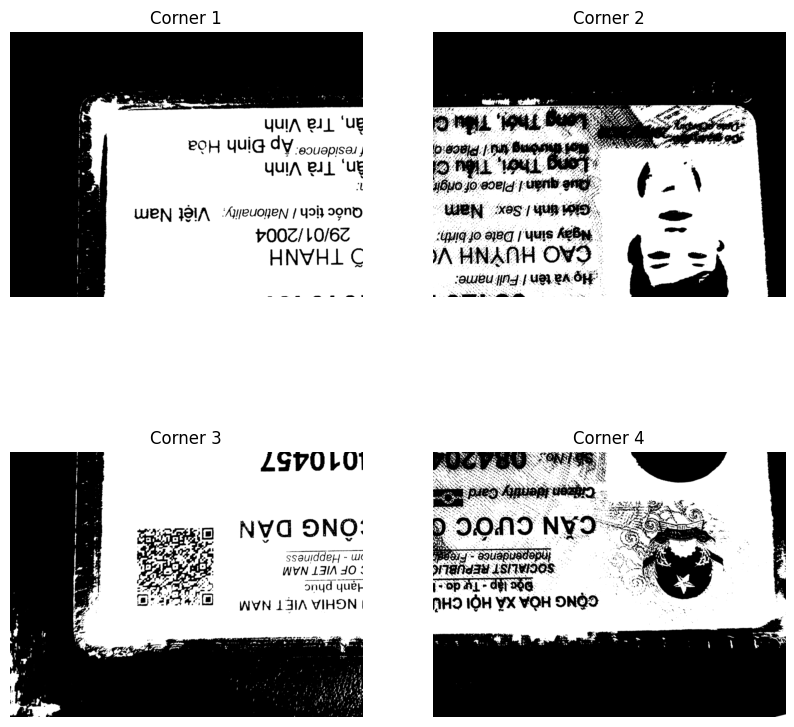

None


In [101]:
img = cv2.imread("E:\\my_id.jpg")  # Đường dẫn đến ảnh của bạn
print(detect_qr_in_zoomed_corners(img))